In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

## FFT

In [2]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [3]:
def FFT_show(data):
    header = "D:/K_sunada/database/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values']
    y = dd['waveform']['values'] - dd['waveform1']['values']
    readout_freq = 10.3e9
    readout_if_freq = 125e6
    readout_lo_freq = readout_freq + readout_if_freq

    x_fft = FFT(x, y)[0]
    y_fft = FFT(x, y)[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2)
    ax1.set_xlabel('time(ns)')
    ax1.set_ylabel('waveform(V)')
    ax1.plot(x,  y)
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")

    ax2.set_xlabel('frequency(Hz)')
    ax2.set_ylabel('Power(a.u.)')
    ax2.plot(readout_lo_freq-x_fft, y_fft)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

    plt.show()
    return peak


In [4]:
def waveform_show(data):
    header = "D:/K_sunada/database/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values']
    y = dd['waveform']['values'] - dd['waveform1']['values']


    fig, (ax1) = plt.subplots(nrows=1)
    ax1.set_xlabel('time(ns)')
    ax1.set_ylabel('waveform(V)')
    ax1.plot(x,  y)
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()

In [5]:
ph0 = "/2023-07-19/2023-07-19T223718_6179d9a5-td_sym_photon_generation"
ph5 = "/2023-07-19/2023-07-19T230115_b9ae83bd-td_sym_photon_generation"
ph10 = "/2023-07-21/2023-07-21T120608_8a2fad4e-td_photon_generation_sym"
ph15 = "/2023-07-19/2023-07-19T230954_ef8a2345-td_sym_photon_generation"
ph20 = "/2023-07-21/2023-07-21T170416_3048cd8c-td_photon_generation_sym"
phmi5 = "/2023-07-19/2023-07-19T182157_b5775a57-td_sym_photon_generation"
phmi10 = "/2023-07-19/2023-07-19T231758_0fe4aac8-td_sym_photon_generation"
phmi15 = "/2023-07-21/2023-07-21T121817_3c981b79-td_photon_generation_sym"
phmi20 = "/2023-07-21/2023-07-21T170936_eea8aa36-td_photon_generation_sym"

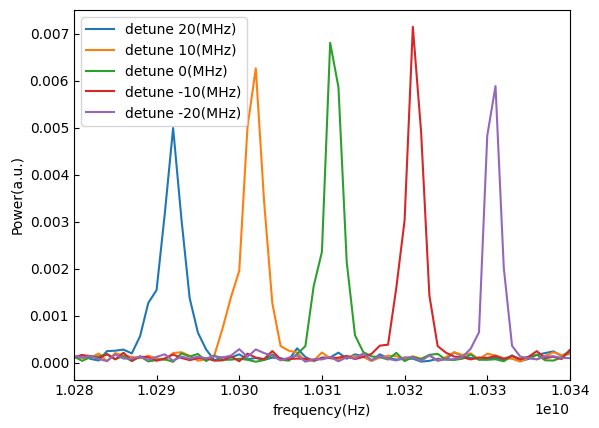

In [ ]:
dd_list=[ph20, ph10, ph0, phmi10, phmi20]
label_list=["detune 20(MHz)", "detune 10(MHz)","detune 0(MHz)","detune -10(MHz)","detune -20(MHz)",]
header = "D:/K_sunada/database/"
x_FFT = []
y_FFT = []

for i in range(5):
    dd = datadict_from_hdf5(header+dd_list[i]+"/data")
    x = dd['time']['values']
    y = dd['waveform']['values'] - dd['waveform1']['values']
    x_fft = FFT(x, y)[0]
    y_fft = FFT(x, y)[1]
    x_FFT.append(x_fft)
    y_FFT.append(y_fft)


readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig,  ax2 = plt.subplots(nrows=1)
# fig, (ax1, ax2) = plt.subplots(nrows=2)
# ax1.set_xlabel('time(ns)')
# ax1.set_ylabel('waveform(V)')
# ax1.plot(x,  y)
# ax1.tick_params(axis="x", direction="in")
# ax1.tick_params(axis="y", direction="in")

ax2.set_xlabel('frequency(Hz)')
ax2.set_ylabel('Fourier amplitude(a.u.)')
for i in range(5):
    label= label_list[i]
    ax2.plot(readout_lo_freq-x_FFT[i], y_FFT[i], label=label)

ax2.legend(label_list)
ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
ax2.set_xlim(1.028e10, 1.034e10)
# peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

plt.show()

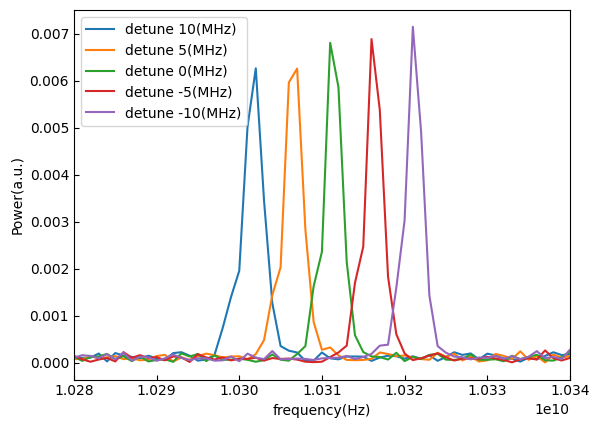

In [310]:
dd_list=[ph10, ph5, ph0, phmi5, phmi10]
label_list=["detune 10(MHz)", "detune 5(MHz)","detune 0(MHz)","detune -5(MHz)","detune -10(MHz)",]
header = "D:/K_sunada/database/"
x_FFT = []
y_FFT = []

for i in range(5):
    dd = datadict_from_hdf5(header+dd_list[i]+"/data")
    x = dd['time']['values']
    y = dd['waveform']['values'] - dd['waveform1']['values']
    x_fft = FFT(x, y)[0]
    y_fft = FFT(x, y)[1]
    x_FFT.append(x_fft)
    y_FFT.append(y_fft)


readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig,  ax2 = plt.subplots(nrows=1)
# fig, (ax1, ax2) = plt.subplots(nrows=2)
# ax1.set_xlabel('time(ns)')
# ax1.set_ylabel('waveform(V)')
# ax1.plot(x,  y)
# ax1.tick_params(axis="x", direction="in")
# ax1.tick_params(axis="y", direction="in")

ax2.set_xlabel('frequency(Hz)')
ax2.set_ylabel('Power(a.u.)')
for i in range(5):
    label= label_list[i]
    ax2.plot(readout_lo_freq-x_FFT[i], y_FFT[i], label=label)

ax2.legend(label_list)
ax2.tick_params(axis="x", direction="in")
ax2.tick_params(axis="y", direction="in")
ax2.set_xlim(1.028e10, 1.034e10)
# peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

plt.show()

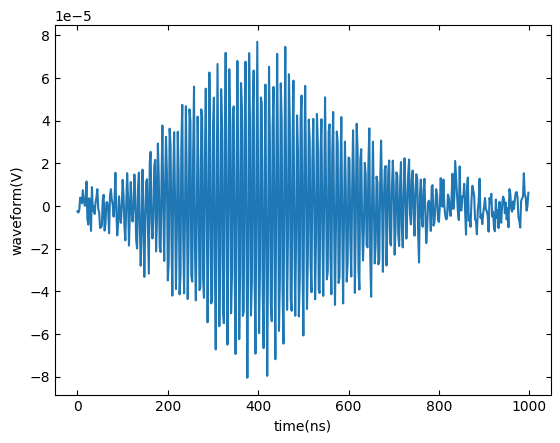

In [6]:
waveform_show(ph0)

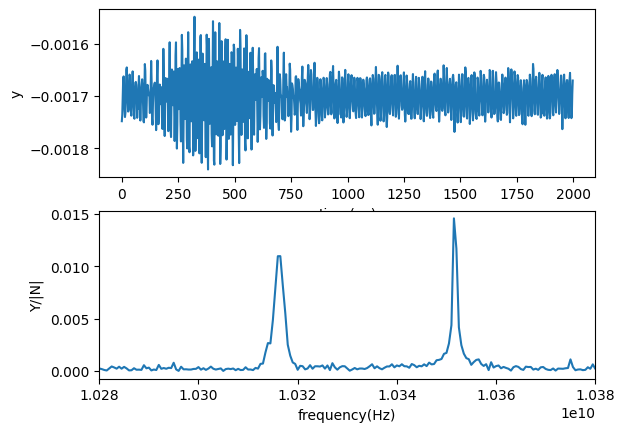

In [ ]:
x_fft = FFT(x, ymi5new)[0]
y_fft = FFT(x, ymi5new)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(xnew,  ymi5new)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

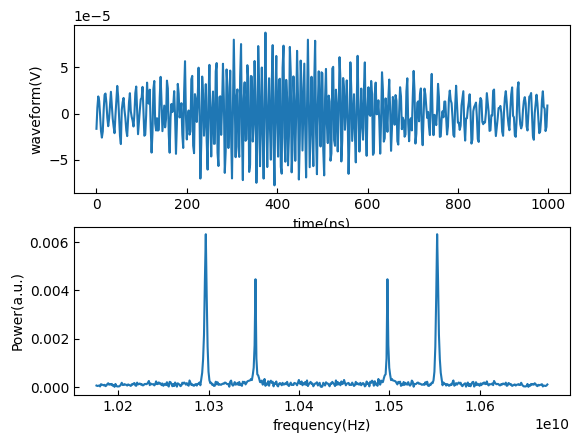

array([1.0553e+10, 1.0297e+10])

In [293]:
FFT_show(ph15)

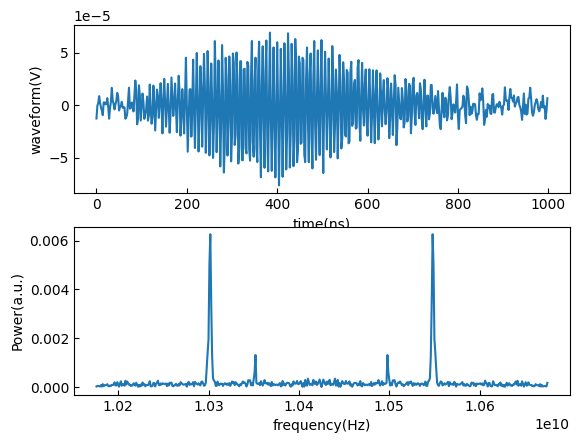

array([1.0548e+10, 1.0302e+10])

In [294]:
FFT_show(ph10)

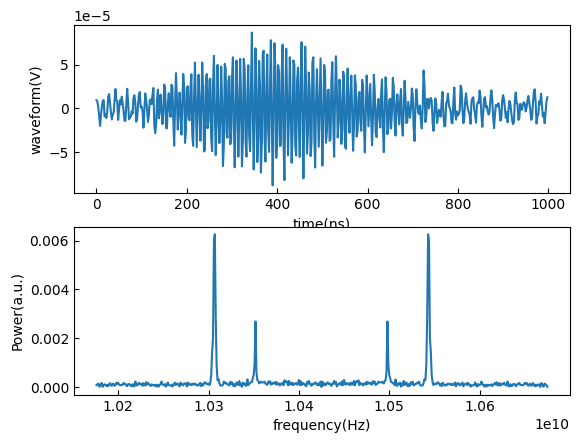

array([1.0543e+10, 1.0307e+10])

In [295]:
FFT_show(ph5)

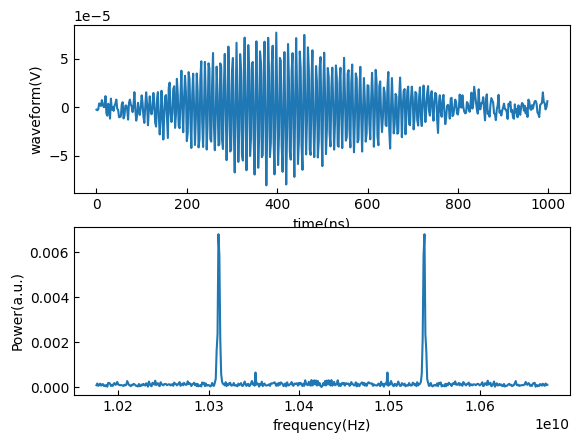

array([1.0539e+10, 1.0311e+10])

In [296]:
FFT_show(ph0)

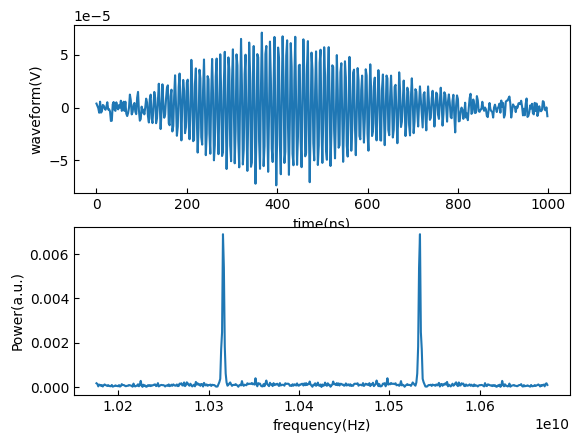

array([1.0534e+10, 1.0316e+10])

In [297]:
FFT_show(phmi5)

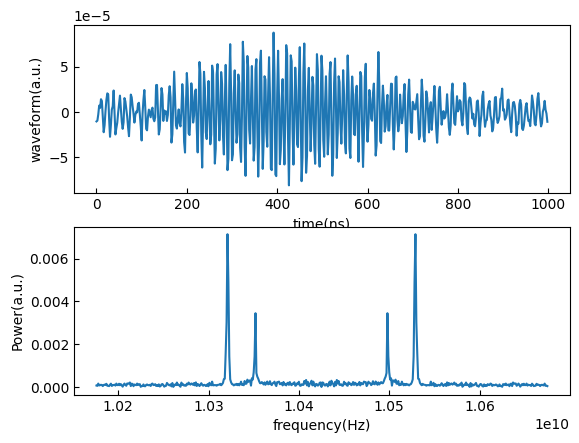

array([1.0529e+10, 1.0321e+10])

In [273]:
FFT_show(phmi10)

In [290]:
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

qubit_lo_freq = 7.92543e9
ge_freq = 8.02e9 + 0.0018e9 
ge_if_freq =ge_freq - qubit_lo_freq
ef_freq = 7.71e9 # + 1.096e4#7.86e9 #7.71e9
ef_if_freq = ef_freq - qubit_lo_freq

anharmonicity = (ef_freq -ge_freq)*1e-9


fogi_lo_freq = 2 * qubit_lo_freq - readout_freq - readout_if_freq
fogi_freq = 5.415e9
fogi_if_freq = fogi_freq - fogi_lo_freq

photon_freq = ge_freq + ef_freq -fogi_freq

print(1.0311e10-photon_freq)

-5800000.0


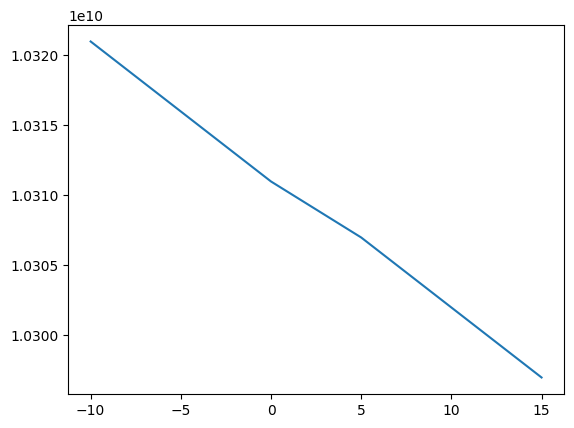

In [280]:
x=[ -10, -5, 0, 5, 10, 15]
y=[ 1.0321e+10,1.0316e+10,1.0311e+10,1.0307e+10,1.0302e+10,1.0297e+10]

plt.plot(x, y)
plt.show()

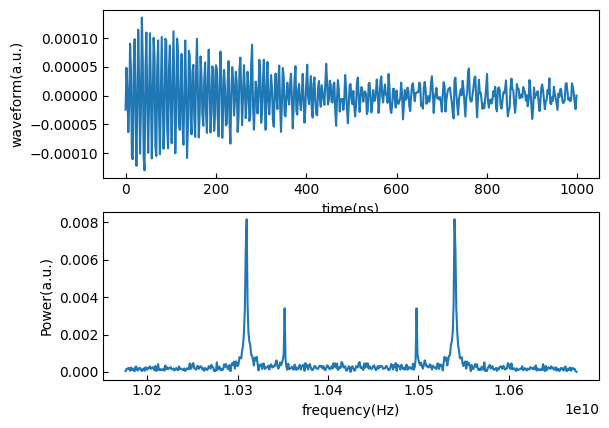

array([1.054e+10, 1.031e+10])

In [269]:
square = "/2023-07-20/2023-07-20T183727_0a4ac8f6-td_photon_generation"
FFT_show(square)

In [120]:
ph0 = "/2023-07-19/2023-07-19T223718_6179d9a5-td_sym_photon_generation"
ph5 = "/2023-07-19/2023-07-19T230115_b9ae83bd-td_sym_photon_generation"
ph10 = ""
ph15 = "/2023-07-19/2023-07-19T230954_ef8a2345-td_sym_photon_generation"
phmi5 = "/2023-07-19/2023-07-19T182157_b5775a57-td_sym_photon_generation"
phmi10 = "/2023-07-19/2023-07-19T231758_0fe4aac8-td_sym_photon_generation"
phmi15 = ""

dd_ph0 = datadict_from_hdf5(header + ph0 +"/data")
dd_ph5 = datadict_from_hdf5(header + ph5 +"/data")
# dd_ph10 = datadict_from_hdf5(header + ph10 +"/data")
dd_ph15 = datadict_from_hdf5(header + ph15 +"/data")
dd_phmi5 = datadict_from_hdf5(header + phmi5 +"/data")
dd_phmi10 = datadict_from_hdf5(header + phmi10 +"/data")
# dd_phmi15 = datadict_from_hdf5(header + phmi15 +"/data")

In [125]:
x = dd_ph0['time']['values']


y0 = dd_ph0['waveform']['values'] - dd_ph0['waveform1']['values']
y5 =  dd_ph5['waveform']['values'] - dd_ph5['waveform1']['values']#-2* dd_ph5['waveform2']['values']
#y10 = dd_ph10['waveform']['values'] - dd_ph10['waveform1']['values']
y15 = dd_ph15['waveform']['values'] - dd_ph15['waveform1']['values']
ymi5 = dd_phmi5['waveform']['values'] - dd_phmi5['waveform1']['values']
ymi10 = dd_phmi10['waveform']['values'] - dd_phmi10['waveform1']['values']
# ymi10 = dd_phmi15['waveform']['values'] - dd_phmi15['waveform1']['values']


In [245]:
square = "/2023-07-20/2023-07-20T183727_0a4ac8f6-td_photon_generation"
dd_squ = datadict_from_hdf5(header + square +"/data")

x_squ = dd_squ['time']['values']
y_squ = dd_squ['waveform']['values'] - dd_squ['waveform1']['values']

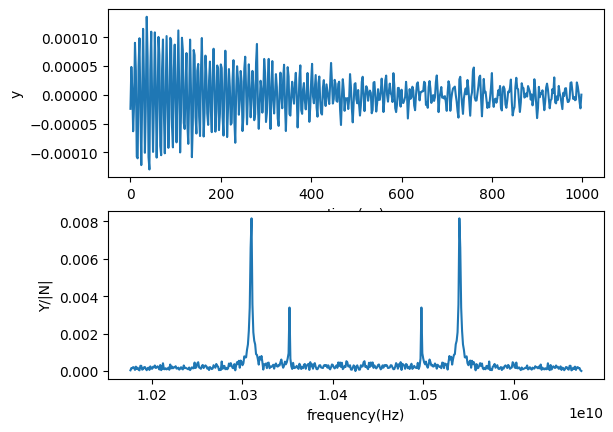

array([1.054e+10, 1.031e+10])

In [246]:
x_squ_fft = FFT(x_squ, y_squ)[0]
y_squ_fft = FFT(x_squ, y_squ)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x_squ,  y_squ)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')

ax02.plot(readout_lo_freq-x_squ_fft, y_squ_fft)

plt.show()

readout_lo_freq-x_squ_fft[signal.argrelmax(y_squ_fft, order=100)]

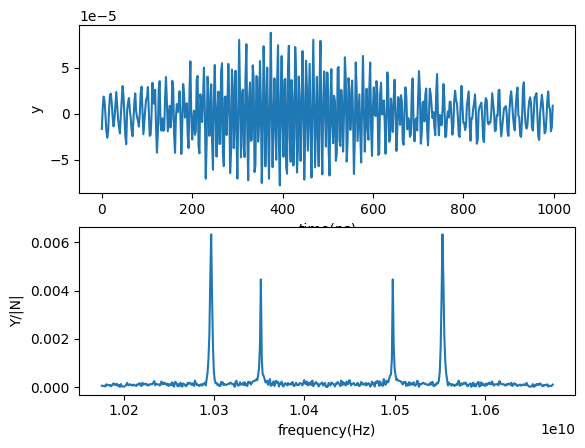

In [213]:
x_fft = FFT(x, y15)[0]
y_fft = FFT(x, y15)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  y15)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')


ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


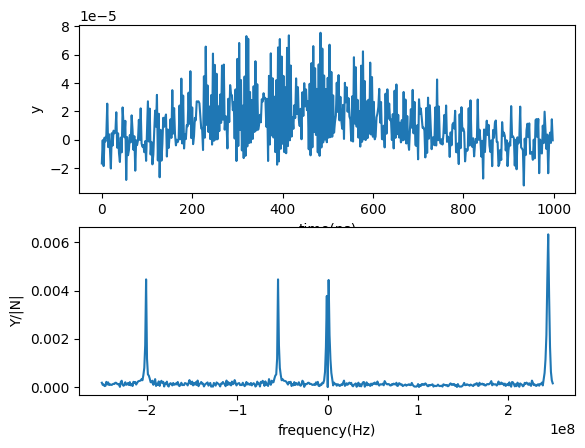

In [216]:
x_fft = FFT(x, (y15*np.exp(-1j*1.28e8*x*1e-9*2*np.pi)))[0]
y_fft = FFT(x,  (y15*np.exp(-1j*1.28e8*x*1e-9*2*np.pi)))[1]
# readout_freq = 10.3e9
# readout_if_freq = 125e6
# readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  (y15*np.exp(-1j*1.28e8*x*1e-9*2*np.pi)))

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(1.2e8, 1.35e8)

ax02.plot(x_fft, y_fft)

plt.show()

In [179]:
x_fft[signal.argrelmax(y_fft, order=100)]

array([-1.28e+08,  1.28e+08])

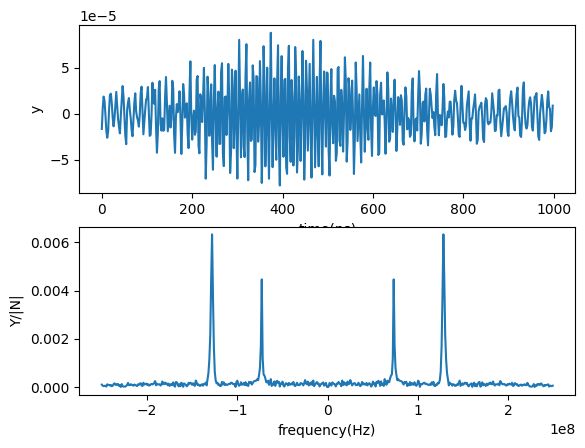

In [159]:
x_fft = FFT(x, y15)[0]
y_fft = FFT(x, y15)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  y15)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(1.2e8, 1.35e8)

ax02.plot(x_fft, y_fft)

plt.show()

In [167]:
x_fft[signal.argrelmax( y_fft, order=100)]

array([-1.28e+08,  1.28e+08])

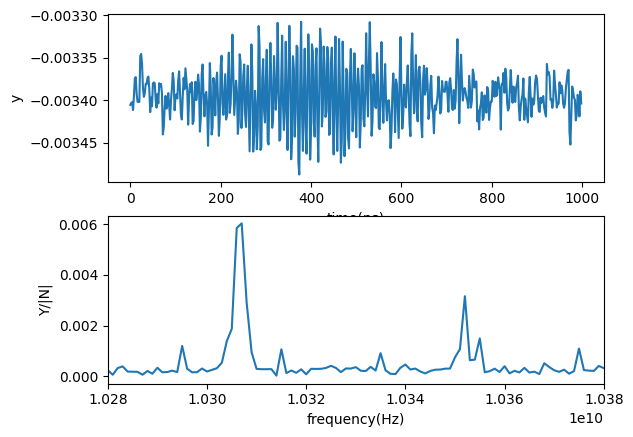

In [124]:
x_fft = FFT(x, y5)[0]
y_fft = FFT(x, y5)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  y5)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

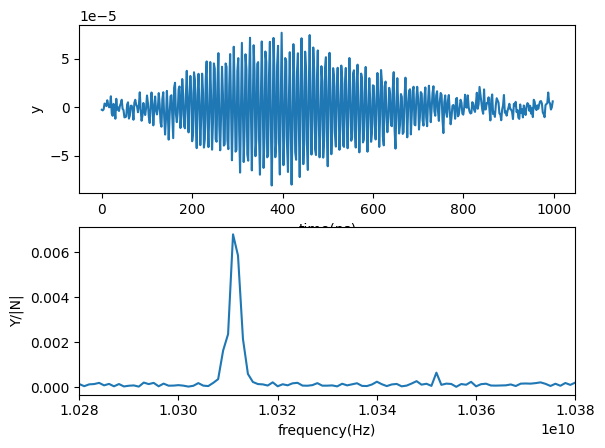

array([1.0539e+10, 1.0311e+10])

In [244]:
x_fft = FFT(x, y0)[0]
y_fft = FFT(x, y0)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  y0)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)
# ax02.plot(x_fft, y_fft)
plt.show()

readout_lo_freq-x_fft[signal.argrelmax( y_fft, order=100)]

In [220]:
def lowpass(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


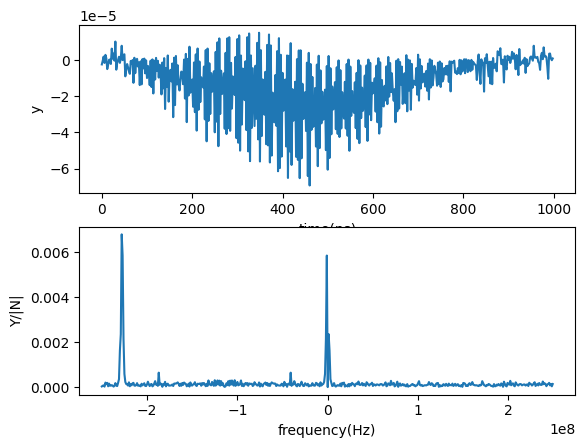

In [221]:
x_fft = FFT(x, (y0*np.exp(-1j*1.14e8*x*1e-9*2*np.pi)))[0]
y_fft = FFT(x, (y0*np.exp(-1j*1.14e8*x*1e-9*2*np.pi)))[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  (y0*np.exp(-1j*1.14e8*x*1e-9*2*np.pi)))

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(x_fft, y_fft)


plt.show()

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


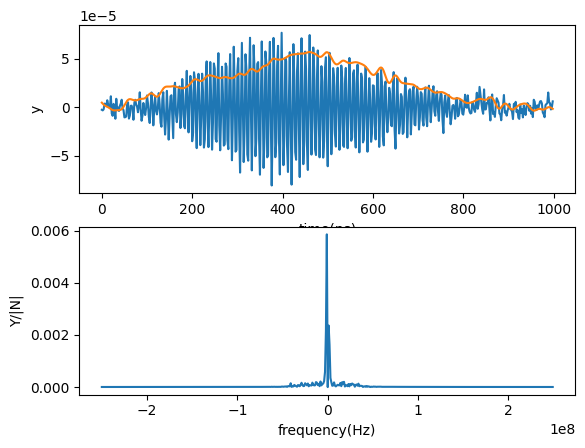

In [242]:
y0low = lowpass( y0*np.exp(-1j*1.14e8*x*1e-9*2*np.pi), 2e-9, -0.1e8, 0.11e8, 2, 40)
y0lowfft = FFT(x, y0low )[1]

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x, y0)
ax01.plot(x, -2* y0low)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(x_fft, y0lowfft)


plt.show()

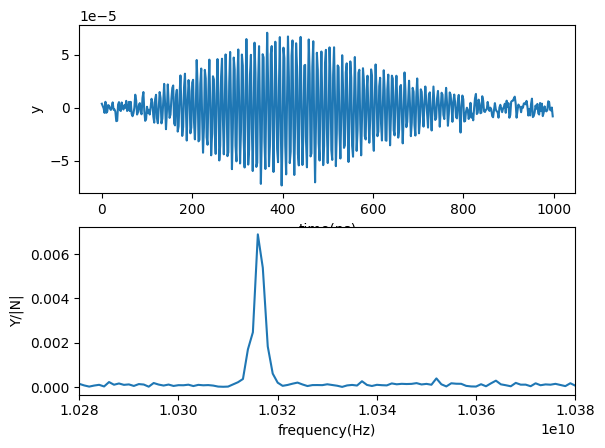

In [92]:
x_fft = FFT(x, ymi5)[0]
y_fft = FFT(x, ymi5)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  ymi5)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

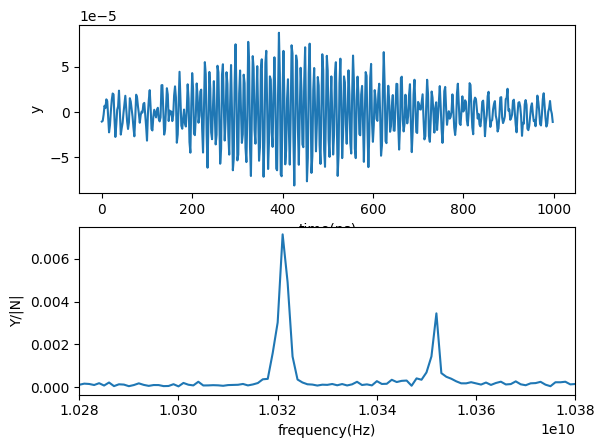

In [122]:
x_fft = FFT(x, ymi10)[0]
y_fft = FFT(x, ymi10)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  ymi10)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

In [73]:
ph0 = "/2023-07-19/2023-07-19T181311_7bc629db-td_sym_photon_generation"
ph5 = "/2023-07-19/2023-07-19T180421_40336667-td_sym_photon_generation"
ph10 = "/2023-07-19/2023-07-19T175504_f411e549-td_sym_photon_generation"
ph15 = "/2023-07-19/2023-07-19T183920_2350e427-td_sym_photon_generation"
phmi5 = "/2023-07-19/2023-07-19T182157_b5775a57-td_sym_photon_generation"
phmi5new = "/2023-07-19/2023-07-19T223718_6179d9a5-td_sym_photon_generation"
phmi10 = "/2023-07-19/2023-07-19T183039_ec970b14-td_sym_photon_generation"
phmi15 = "/2023-07-19/2023-07-19T184936_9233dcd0-td_sym_photon_generation"
ph5new = "/2023-07-19/2023-07-19T201641_bc67d265-td_sym_photon_generation"
pulsecheck = "/2023-07-19/2023-07-19T194634_8796803c-td_pulse_check"
pulsecheck1 = "/2023-07-19/2023-07-19T200016_716b4c01-td_pulse_check"
pulsecheck3 = "/2023-07-19/2023-07-19T193502_ead1203d-td_pulse_check"
pulsecheck4 = "/2023-07-19/2023-07-19T192945_2ddc0b43-td_pulse_check"
phzero = "/2023-07-19/2023-07-19T202210_80f92665-td_sym_photon_generation"

dd_ph0 = datadict_from_hdf5(header + ph0 +"/data")
dd_ph5 = datadict_from_hdf5(header + ph5 +"/data")
dd_ph10 = datadict_from_hdf5(header + ph10 +"/data")
dd_ph15 = datadict_from_hdf5(header + ph15 +"/data")
dd_phmi5 = datadict_from_hdf5(header + phmi5 +"/data")
dd_phmi5new = datadict_from_hdf5(header + phmi5new +"/data")
dd_phmi10 = datadict_from_hdf5(header + phmi10 +"/data")
dd_phmi15 = datadict_from_hdf5(header + phmi15 +"/data")
dd_ph5new = datadict_from_hdf5(header + ph5new +"/data")
dd_pulsecheck = datadict_from_hdf5(header + pulsecheck +"/data")
dd_pulsecheck1 = datadict_from_hdf5(header + pulsecheck1 +"/data")
dd_pulsecheck3 = datadict_from_hdf5(header + pulsecheck3 +"/data")
dd_pulsecheck4 = datadict_from_hdf5(header + pulsecheck4 +"/data")
dd_phzero = datadict_from_hdf5(header + phzero +"/data")

In [86]:
x = dd_ph0['time']['values']
xnew = dd_ph5new['time']['values']
xpulsecheck = dd_pulsecheck['time']['values']
xzero = dd_phzero['time']['values']

y0 = dd_ph0['waveform']['values'] - dd_ph0['waveform1']['values']
y5 = dd_ph5['waveform']['values'] - dd_ph5['waveform1']['values']
y10 = dd_ph10['waveform']['values'] - dd_ph10['waveform1']['values']
y15 = dd_ph15['waveform']['values'] - dd_ph15['waveform1']['values']
ymi5 = dd_phmi5['waveform']['values'] - dd_phmi5['waveform1']['values']
ymi5new = dd_phmi5new['waveform']['values'] - dd_phmi5new['waveform1']['values']#+ dd_phmi5new['waveform2']['values']
ymi10 = dd_phmi10['waveform']['values'] - dd_phmi10['waveform1']['values']
ymi10 = dd_phmi15['waveform']['values'] - dd_phmi15['waveform1']['values']
y5new = dd_ph5new['waveform']['values'] - dd_ph5new['waveform1']['values']
ypulsecheck = dd_pulsecheck['voltage']['values'] -dd_pulsecheck1['voltage']['values']
ypulsecheck1 = dd_pulsecheck3['voltage']['values'] -dd_pulsecheck4['voltage']['values']
yzero = dd_phzero['waveform']['values'] - dd_phzero['waveform1']['values']

## FFT

In [57]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

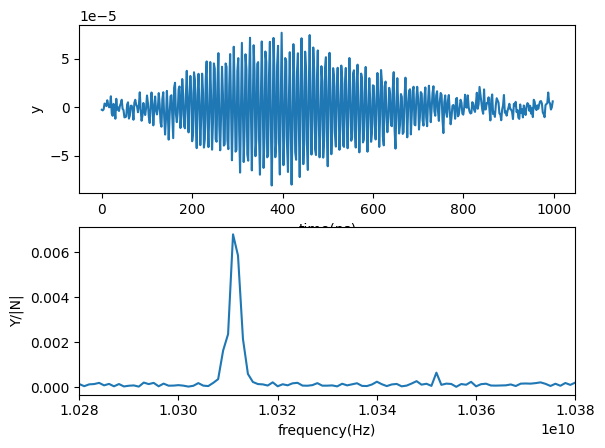

In [87]:
x_fft = FFT(x, ymi5new)[0]
y_fft = FFT(x, ymi5new)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  ymi5new)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

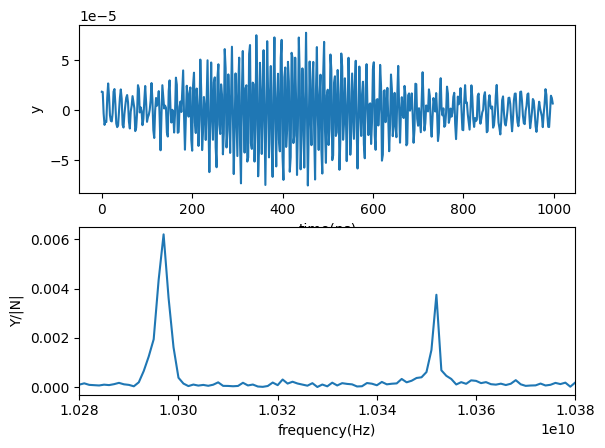

In [58]:
x_fft = FFT(x, y15)[0]
y_fft = FFT(x, y15)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(x,  y15)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

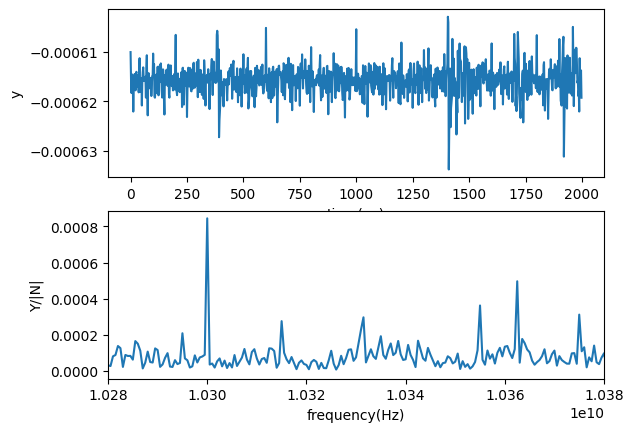

In [28]:
x_fft = FFT(x, ypulsecheck1)[0]
y_fft = FFT(x, ypulsecheck1)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(xpulsecheck,  ypulsecheck1)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(10.28e9, 10.38e9)
# ax02.plot(x_fft, y_fft)
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

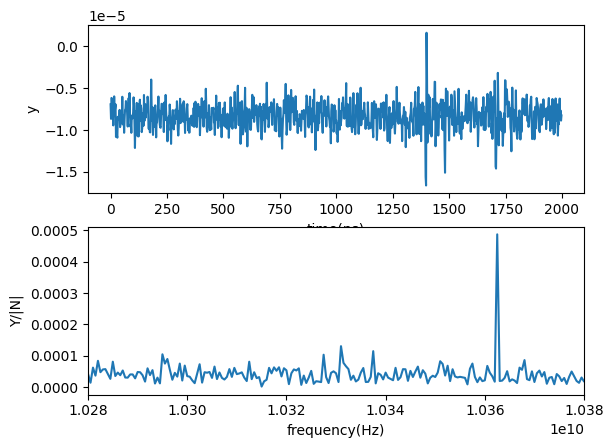

In [25]:
x_fft = FFT(x, ypulsecheck)[0]
y_fft = FFT(x, ypulsecheck)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(xpulsecheck,  ypulsecheck)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(10.28e9, 10.38e9)
# ax02.plot(x_fft, y_fft)
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

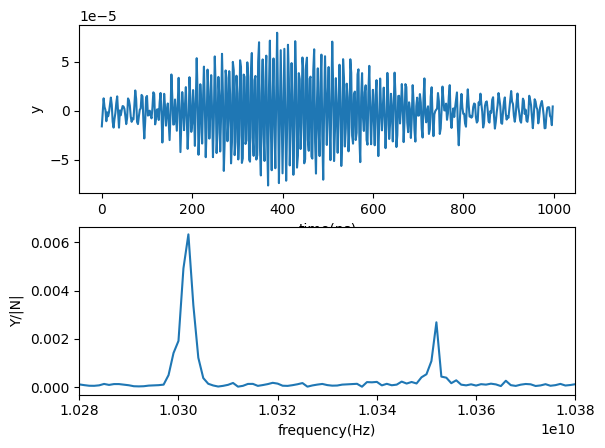

In [ ]:
x_fft = FFT(x, y10)[0]
y_fft = FFT(x, y10)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(t,  y10)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

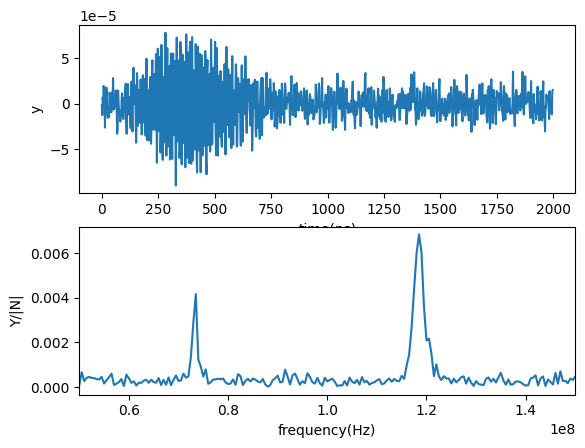

In [ ]:
x_fft = FFT(xnew, y5new)[0]
y_fft = FFT(xnew, y5new)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(2 * np.arange(len(y5new)),  y5new)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
# ax02.set_xlim(10.28e9, 10.38e9)
# ax02.plot(readout_lo_freq-x_fft, y_fft)
ax02.set_xlim(.05e9, 0.15e9)
ax02.plot(x_fft, y_fft)

plt.show()

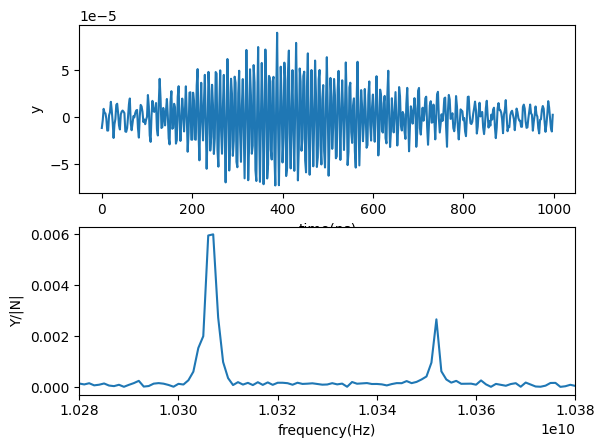

In [ ]:
x_fft = FFT(x, y5)[0]
y_fft = FFT(x, y5)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(t,  y5)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

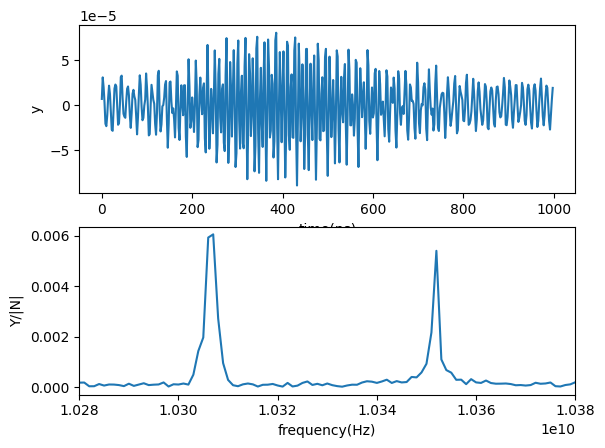

In [ ]:
x_fft = FFT(x, y0)[0]
y_fft = FFT(x, y0)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(t,  y0)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

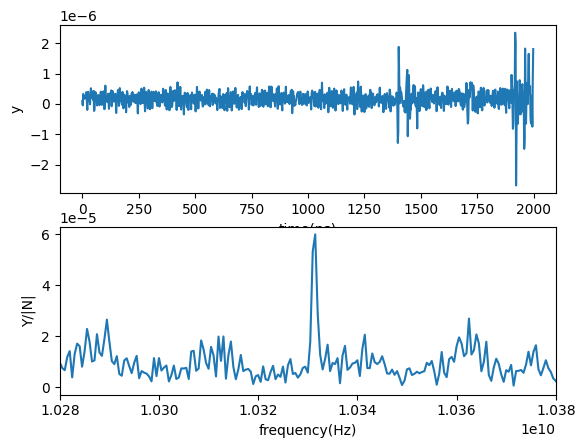

In [47]:
x_fft = FFT(x, yzero)[0]
y_fft = FFT(x, yzero)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(xzero,  yzero)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

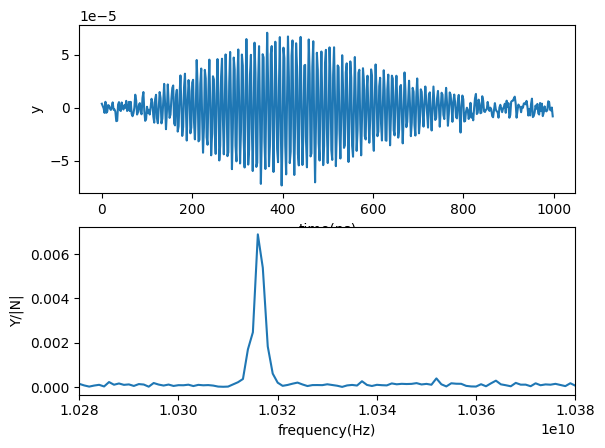

In [ ]:
x_fft = FFT(x, ymi5)[0]
y_fft = FFT(x, ymi5)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(t,  ymi5)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)

ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

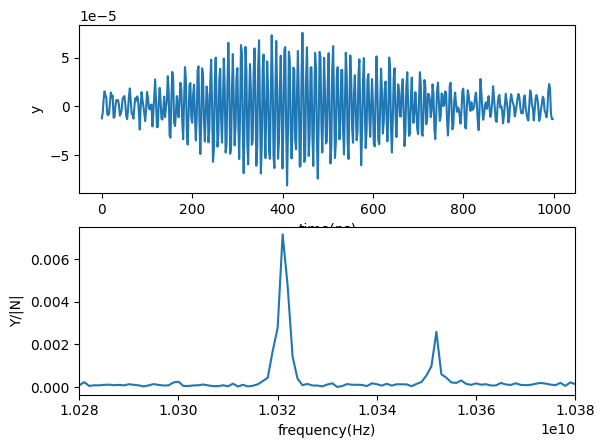

In [ ]:
x_fft = FFT(x, ymi10)[0]
y_fft = FFT(x, ymi10)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(t,  ymi10)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

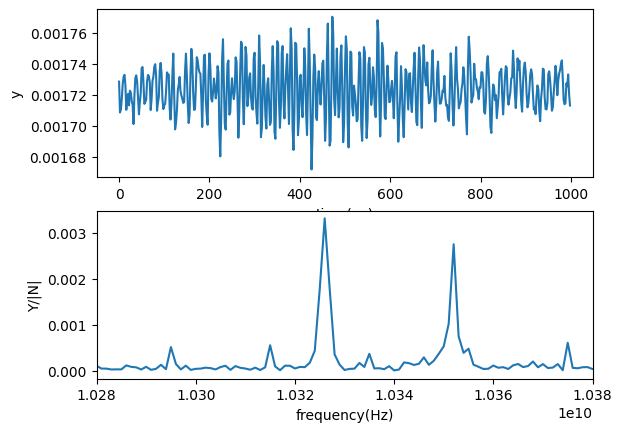

In [ ]:
x_fft = FFT(x, ymi15)[0]
y_fft = FFT(x, ymi15)[1]
readout_freq = 10.3e9
readout_if_freq = 125e6
readout_lo_freq = readout_freq + readout_if_freq

fig, (ax01, ax02) = plt.subplots(nrows=2)
ax01.set_xlabel('time(ns)')
ax01.set_ylabel('y')
ax01.plot(t,  ymi15)

ax02.set_xlabel('frequency(Hz)')
ax02.set_ylabel('Y/|N|')
ax02.set_xlim(10.28e9, 10.38e9)
ax02.plot(readout_lo_freq-x_fft, y_fft)

plt.show()

In [ ]:
fig = plt.figure(figsize = (10, 6))

ax0 = fig.add_subplot(2, 2, 1)
ax5 = fig.add_subplot(2, 2, 2)
ax10 = fig.add_subplot(2, 2, 3)
ax15 = fig.add_subplot(2, 2, 4)
# ax20 = fig.add_subplot(2, 2, 5)
# ax25 = fig.add_subplot(2, 2, 6)
# ax30 = fig.add_subplot(2, 2, 7)

ax0.plot(x, y0, label=d0)
ax5.plot(x, y5, label=d5)
ax10.plot(x, y10, label=d10)
ax15.plot(x, y15, label=d15)
# ax20.plot(x, y20, label=d20)
# ax25.plot(x, y25, label=d25)
# ax30.plot(x, y30, label=d30)

plt.show()